## Employee Sentiment Analysis

### Executive Overview
This notebook analyzes employee email dataset to evaluate sentiment trends, engagement signals, and potential flight risk.

**Key Tasks**
1. Label sentiment for each message (Positive / Neutral / Negative).
2. Explore sentiment distribution and trends over time (EDA).
3. Calculate monthly sentiment scores for each employee.
4. Rank and identify top positive and top negative employees by month.
5. Detect flight risk of employees using a rolling 30 day window.
6. Develop a model to analyze sentiment trends and predict sentiment scores.

### Sentiment labeling 
To balance speed and accuracy, we apply both VADER and RoBERTa:

VADER (baseline, fast): Label all messages quickly using a lexicon-based method.  
RoBERTa (refinement, contextual):Re-check only messages that VADER flags as Negative to reduce false negatives caused by workplace “problem-solving” language.

The final label used for downstream analysis is "final_sentiment" (VADER for all messages, RoBERTa override for VADER-negative messages).


In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../Data/test.csv")
df.head()

,Subject,body,date,from
0,EnronOptions Update!,EnronOptions Announcement\n\n\nWe have updated...,5/10/2010,sally.beck@enron.com
1,(No Subject),"Marc,\n\nUnfortunately, today is not going to ...",7/29/2010,eric.bass@enron.com
2,Phone Screen Interview - Shannon L. Burnham,"When: Wednesday, June 06, 2001 10:00 AM-11:00 ...",7/25/2011,sally.beck@enron.com
3,RE: My new work email,we were thinking papasitos (we can meet somewh...,3/25/2010,johnny.palmer@enron.com
4,Bet,Since you never gave me the $20 for the last t...,5/21/2011,lydia.delgado@enron.com


In [2]:
df.shape
df.columns

Index(['Subject', 'body', 'date', 'from'], dtype='object')

In [3]:
df.isna().sum()

Subject    0
body       0
date       0
from       0
dtype: int64

In [4]:
df["Subject"] = df["Subject"].fillna("")
df["body"] = df["body"].fillna("")

### Task1 Sentiment Labeling

Create a text column. The text column is subject + body.

In [5]:
df["text"] = (
    df["Subject"].astype(str).str.strip()
    + "\n"
    + df["body"].astype(str).str.strip()
)

In [6]:
df[["Subject", "body", "text"]].head(5)

,Subject,body,text
0,EnronOptions Update!,EnronOptions Announcement\n\n\nWe have updated...,EnronOptions Update!\nEnronOptions Announcemen...
1,(No Subject),"Marc,\n\nUnfortunately, today is not going to ...","(No Subject)\nMarc,\n\nUnfortunately, today is..."
2,Phone Screen Interview - Shannon L. Burnham,"When: Wednesday, June 06, 2001 10:00 AM-11:00 ...",Phone Screen Interview - Shannon L. Burnham\n...
3,RE: My new work email,we were thinking papasitos (we can meet somewh...,RE: My new work email\nwe were thinking papasi...
4,Bet,Since you never gave me the $20 for the last t...,Bet\nSince you never gave me the $20 for the l...


In [7]:
df["date"] = df["date"].astype(str).str.strip()
df["date_dt"] = pd.to_datetime(df["date"], errors="coerce")

In [8]:
df[df["date_dt"].isna()].head()

,Subject,body,date,from,text,date_dt


In [9]:
df = df.dropna(subset=["date_dt"]).copy()

In [10]:
df["employee"] = df["from"].astype(str).str.lower().str.strip()

In [11]:
# You should install nltk for the first time
!pip -q install nltk

In [12]:
import nltk
nltk.download("vader_lexicon")
from nltk.sentiment import SentimentIntensityAnalyzer

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\pc\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [13]:
sia = SentimentIntensityAnalyzer()

def label_sentiment(text):
    score = sia.polarity_scores(text)["compound"]
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"


To quickly label employee messages with sentiment categories (Positive, Negative, Neutral), 
we applied the VADER sentiment analysis model from the NLTK library. VADER produces a compound sentiment score ranging from -1 to +1. 
Based on commonly accepted thresholds, messages were labeled as: Positive if compound score ≥ 0.05;  Negative if compound score ≤ -0.05;  Neutral otherwise  

In [14]:
df["sentiment"] = df["text"].apply(label_sentiment)

In [15]:
df["sentiment"].value_counts()

sentiment
Positive    1574
Neutral      454
Negative     163
Name: count, dtype: int64

### Task1b Sentiment Refinement (RoBERTa Audit on VADER-Negative Messages)

VADER is efficient but it may misread workplace problem-solving word such as "issue", "risk", "problem" and so on, so that it may mislabel these emails as negative sentiment.  
To improve precision for negative detection, we apply a transformer-based model (RoBERTa) as a verifier only on messages initially labeled Negative by VADER.

Outputs created here:  
"sentiment_vader": baseline label for all messages  
"sentiment_roberta": RoBERTa label for the VADER-negative subset  
"final_sentiment": final label used in Task2–Task6


In [16]:
# You Should install the transformers in the first time.
!pip -q install transformers

C:\Users\pc\anaconda3\envs\pytorch\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


Total messages identified as 'Negative' by VADER: 163

RoBERTa Refinement Results (Sum should equal total VADER-Negative):
final_sentiment
Neutral     108
Negative     51
Positive      4
Name: count, dtype: int64

Verification Sum: 163 (Match: True)


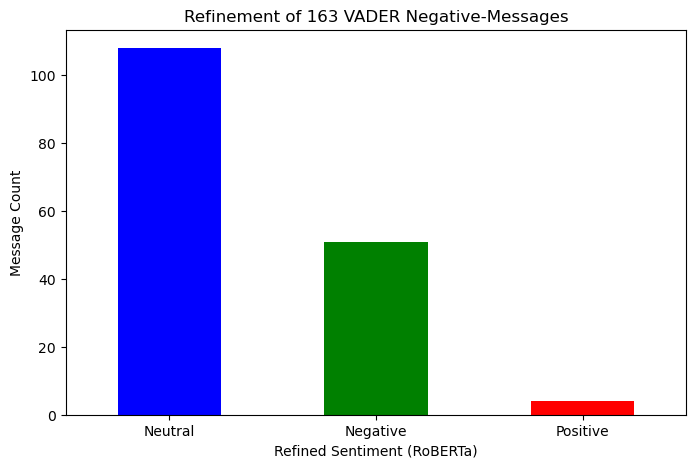

In [17]:
import numpy as np
import pandas as pd
from transformers import pipeline
import matplotlib.pyplot as plt
df["sentiment_vader"] = df["sentiment"]

roberta_pipe = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    tokenizer="cardiffnlp/twitter-roberta-base-sentiment-latest",
    device=-1
)
# If you have GPU, just change device = -1 to device = 0; If you only have cpu, keep device = -1
neg_mask = df["sentiment_vader"] == "Negative"
texts = df.loc[neg_mask, "text"].fillna("").astype(str).tolist()

BATCH_SIZE = 8
roberta_preds = []

for i in range(0, len(texts), BATCH_SIZE):
    batch = texts[i:i+BATCH_SIZE]
    roberta_preds.extend(
        roberta_pipe(batch, truncation=True, max_length=512)
    )

def map_roberta_label(pred_label: str) -> str:
    lab = str(pred_label).lower()
    if "positive" in lab or lab == "label_2":
        return "Positive"
    elif "neutral" in lab or lab == "label_1":
        return "Neutral"
    elif "negative" in lab or lab == "label_0":
        return "Negative"
    return "Neutral"

df["sentiment_roberta"] = pd.NA
df.loc[neg_mask, "sentiment_roberta"] = [map_roberta_label(p["label"]) for p in roberta_preds]

df["final_sentiment"] = df["sentiment_vader"]
df.loc[neg_mask, "final_sentiment"] = df.loc[neg_mask, "sentiment_roberta"]

total_vader_neg = df[neg_mask].shape[0]
print(f"Total messages identified as 'Negative' by VADER: {total_vader_neg}")

refinement_distribution = df.loc[neg_mask, "final_sentiment"].value_counts()

print("\nRoBERTa Refinement Results (Sum should equal total VADER-Negative):")
print(refinement_distribution)
print(f"\nVerification Sum: {refinement_distribution.sum()} (Match: {refinement_distribution.sum() == total_vader_neg})")

plt.figure(figsize=(8, 5))
refinement_distribution.plot(kind='bar', color=['blue', 'green', 'red'])
plt.title(f"Refinement of {total_vader_neg} VADER Negative-Messages")
plt.xlabel("Refined Sentiment (RoBERTa)")
plt.ylabel("Message Count")
plt.xticks(rotation=0) 
plt.show()

In [18]:
print(df.columns.tolist())

['Subject', 'body', 'date', 'from', 'text', 'date_dt', 'employee', 'sentiment', 'sentiment_vader', 'sentiment_roberta', 'final_sentiment']


In [19]:
print(df["final_sentiment"].value_counts())

final_sentiment
Positive    1578
Neutral      562
Negative      51
Name: count, dtype: int64


A total of 2,191 employee messages are first labeled using the VADER sentiment analyzer. Then I find that too many emails are labeled negative, so I apply RoBERTa to refine the results. According to the results, most of the "negative" emails after VADER are actually neutral, and only 51 are identified negative finally. The majority of messages are classified as Positive, followed by Neutral and Negative sentiments, which aligns with typical patterns observed in internal corporate communication.


### Task2 Exploratory Data Analysis (EDA)

In [20]:
df["month"] = df["date_dt"].dt.to_period("M").astype(str)

In [21]:
df[["date", "date_dt", "month"]].head()

,date,date_dt,month
0,5/10/2010,2010-05-10,2010-05
1,7/29/2010,2010-07-29,2010-07
2,7/25/2011,2011-07-25,2011-07
3,3/25/2010,2010-03-25,2010-03
4,5/21/2011,2011-05-21,2011-05


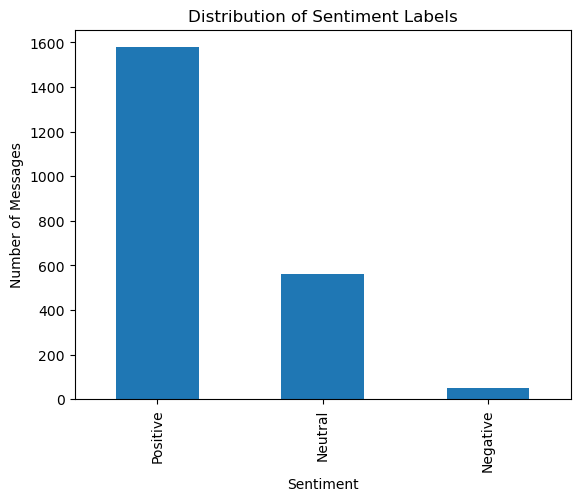

In [22]:
import matplotlib.pyplot as plt

sentiment_counts = df["final_sentiment"].value_counts()

plt.figure()
sentiment_counts.plot(kind="bar")
plt.title("Distribution of Sentiment Labels")
plt.xlabel("Sentiment")
plt.ylabel("Number of Messages")
plt.show()


In [23]:
monthly_sentiment = (
    df.groupby(["month", "final_sentiment"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

monthly_sentiment = monthly_sentiment.reset_index()

monthly_sentiment.columns.name = None

monthly_sentiment.head()

,month,Negative,Neutral,Positive
0,2010-01,2,26,63
1,2010-02,3,31,57
2,2010-03,3,29,59
3,2010-04,2,26,64
4,2010-05,1,28,62


<Figure size 640x480 with 0 Axes>

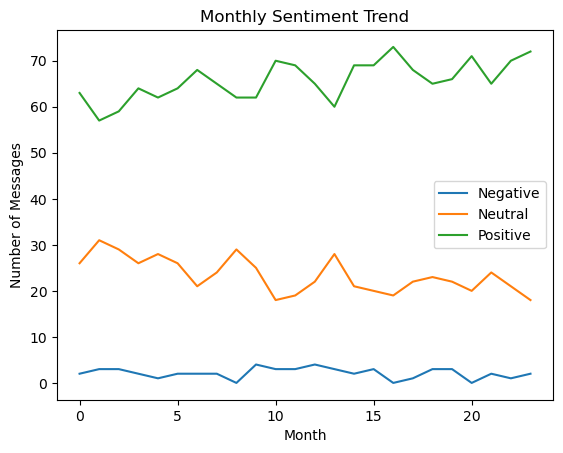

In [24]:
plt.figure()
monthly_sentiment.plot()
plt.title("Monthly Sentiment Trend")
plt.xlabel("Month")
plt.ylabel("Number of Messages")
plt.show()


The monthly sentiment trend indicates that the number of positive sentiment is most among employee communication across all months. Positive messages remain consistently high, while neutral messages show moderate fluctuations and negative messages stay at a very low level throughout the period. 

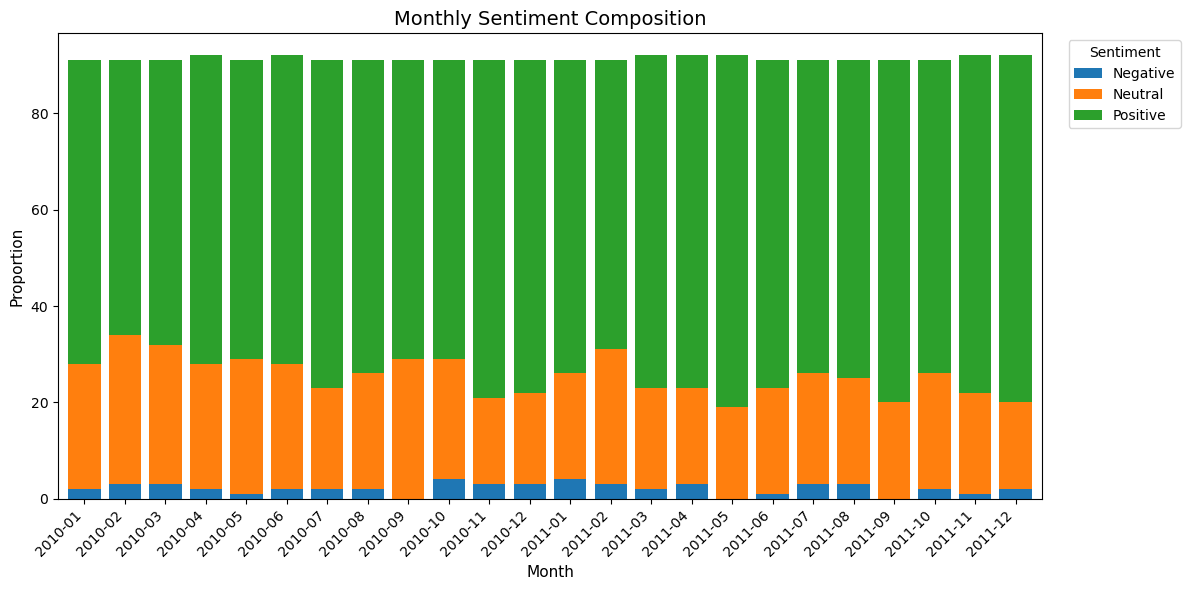

In [25]:
monthly_pct = monthly_sentiment.set_index("month")
ax = monthly_pct[["Negative", "Neutral", "Positive"]].plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    width=0.8
)

ax.set_title("Monthly Sentiment Composition", fontsize=14)
ax.set_xlabel("Month", fontsize=11)
ax.set_ylabel("Proportion", fontsize=11)
ax.legend(title="Sentiment", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=45, ha="right")
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

Positive emotions have always dominated monthly emails, typically accounting for two-thirds to three-quarters of all emails. Neutral emotions are the second largest category, exhibiting moderate fluctuations over several months, while negative emotions remain relatively small throughout the entire period, typically close to zero.

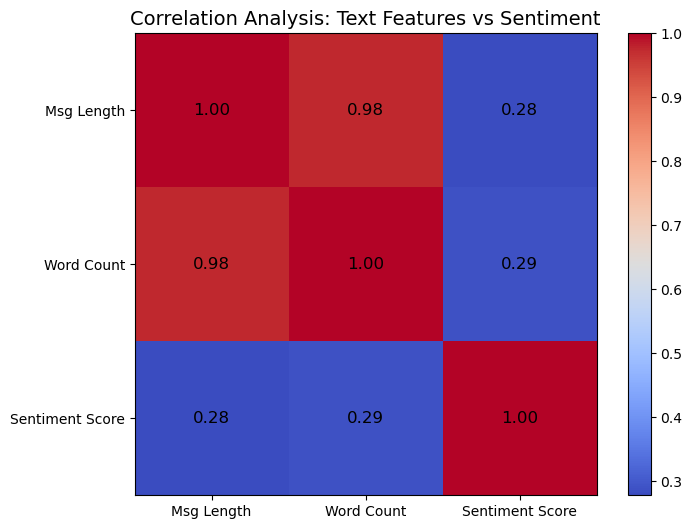

In [26]:
df['message_length'] = df['text'].fillna('').str.len()
df['word_count'] = df['text'].fillna('').str.split().str.len()

mapping = {"Positive": 1, "Neutral": 0, "Negative": -1}
df['sentiment_score'] = df['final_sentiment'].map(mapping)

corr_matrix = df[['message_length', 'word_count', 'sentiment_score']].corr()

plt.figure(figsize=(8, 6))
im = plt.imshow(corr_matrix, cmap='coolwarm', interpolation='nearest')
plt.colorbar(im)

cols = ['Msg Length', 'Word Count', 'Sentiment Score']
plt.xticks(range(len(cols)), cols)
plt.yticks(range(len(cols)), cols)

for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        plt.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', 
                 ha="center", va="center", color="black", fontsize=12)

plt.title("Correlation Analysis: Text Features vs Sentiment", fontsize=14)
plt.show()

Message length and word count are highly correlated at 0.98, meaning they reflect very similar information. Their correlations with sentiment score are much weaker at 0.28 and 0.29, which suggests that longer emails are only slightly associated with more positive sentiment. Overall, text length has limited power in explaining sentiment.

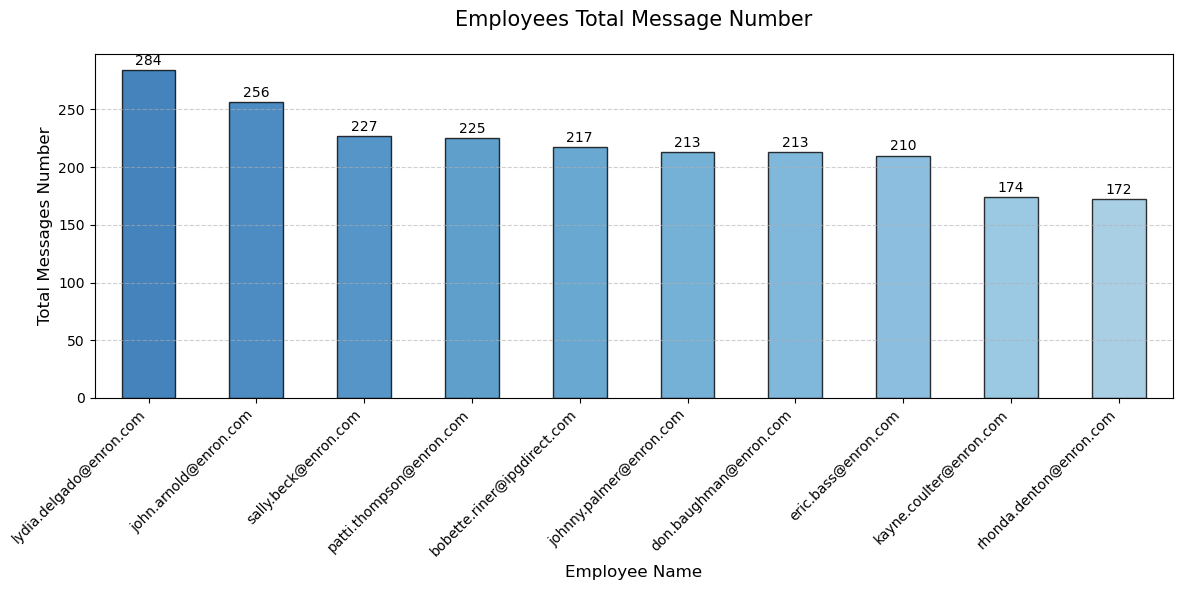

In [27]:
top_senders = df['employee'].value_counts()
plt.figure(figsize=(12, 6))
colors = plt.cm.Blues(np.linspace(0.8, 0.4, len(top_senders)))
top_senders.plot(kind='bar', color=colors, edgecolor='black', alpha=0.8)

plt.title('Employees Total Message Number', fontsize=15, pad=20)
plt.xlabel('Employee Name', fontsize=12)
plt.ylabel('Total Messages Number', fontsize=12)

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)

for i, v in enumerate(top_senders):
    plt.text(i, v + 2, str(v), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

There is a significant difference between the first two and the last two employees. The number of emails sent by the six people in the middle is similar.

### Task3 Employee Score Calculation

In [28]:
df.columns

Index(['Subject', 'body', 'date', 'from', 'text', 'date_dt', 'employee',
       'sentiment', 'sentiment_vader', 'sentiment_roberta', 'final_sentiment',
       'month', 'message_length', 'word_count', 'sentiment_score'],
      dtype='object')

In [29]:
sentiment_score_map = {
    "Positive": 1,
    "Neutral": 0,
    "Negative": -1
}

df["sentiment_score"] = df["final_sentiment"].map(sentiment_score_map)


In [30]:
df[["final_sentiment", "sentiment_score"]].head(10)

,final_sentiment,sentiment_score
0,Positive,1
1,Positive,1
2,Neutral,0
3,Neutral,0
4,Positive,1
5,Positive,1
6,Neutral,0
7,Positive,1
8,Positive,1
9,Neutral,0


In [31]:
monthly_employee_score = (
    df
    .groupby(["employee", "month"])["sentiment_score"]
    .sum()
    .reset_index()
)


In [32]:
monthly_employee_score.head(25)


,employee,month,sentiment_score
0,bobette.riner@ipgdirect.com,2010-01,1
1,bobette.riner@ipgdirect.com,2010-02,9
2,bobette.riner@ipgdirect.com,2010-03,6
3,bobette.riner@ipgdirect.com,2010-04,3
4,bobette.riner@ipgdirect.com,2010-05,3
5,bobette.riner@ipgdirect.com,2010-06,2
6,bobette.riner@ipgdirect.com,2010-07,9
7,bobette.riner@ipgdirect.com,2010-08,6
8,bobette.riner@ipgdirect.com,2010-09,8
9,bobette.riner@ipgdirect.com,2010-10,6


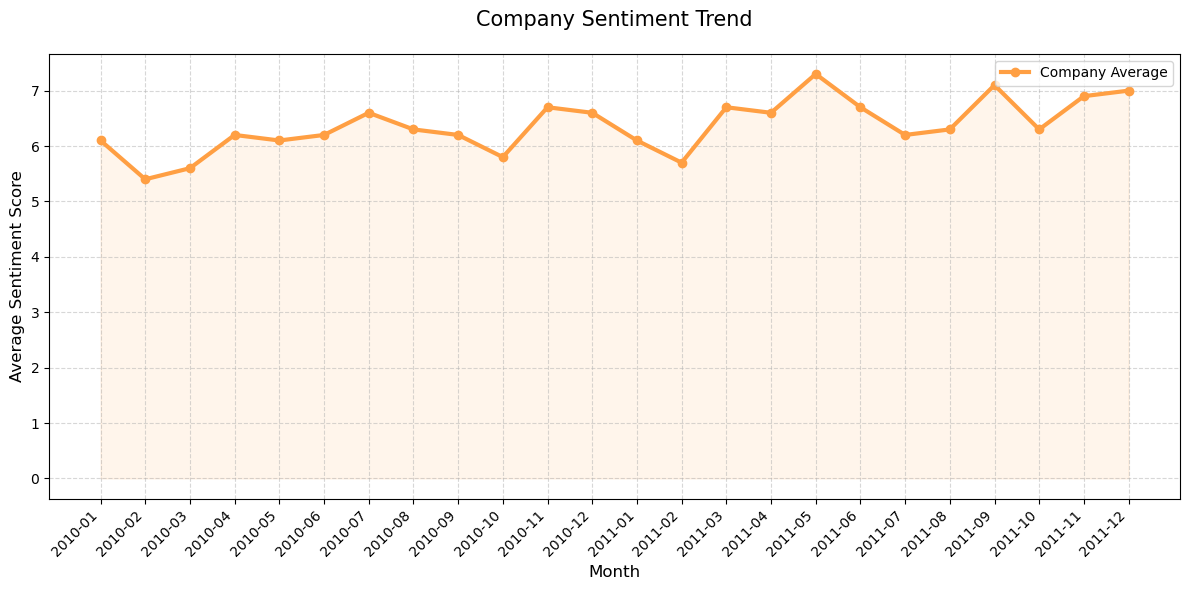

In [33]:
import matplotlib.pyplot as plt

company_trend = monthly_employee_score.groupby('month')['sentiment_score'].mean()

plt.figure(figsize=(12, 6))
plt.plot(company_trend.index, company_trend.values, marker='o', linestyle='-', color='#FF9F43', linewidth=3, label='Company Average')
plt.fill_between(company_trend.index, company_trend.values, color='#FF9F43', alpha=0.1)

plt.title('Company Sentiment Trend', fontsize=15, pad=20)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Sentiment Score', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

The monthly sentiment trend shows that the company's average sentiment remained consistently positive over time, generally fluctuating between 5.4 and 7.3. Although there were some moderate month-to-month changes, the overall pattern is relatively stable, with no sharp drops or prolonged negative periods. Compared with 2010, the average sentiment in 2011 appears slightly higher, and several months in mid to late 2011 reached peak levels.

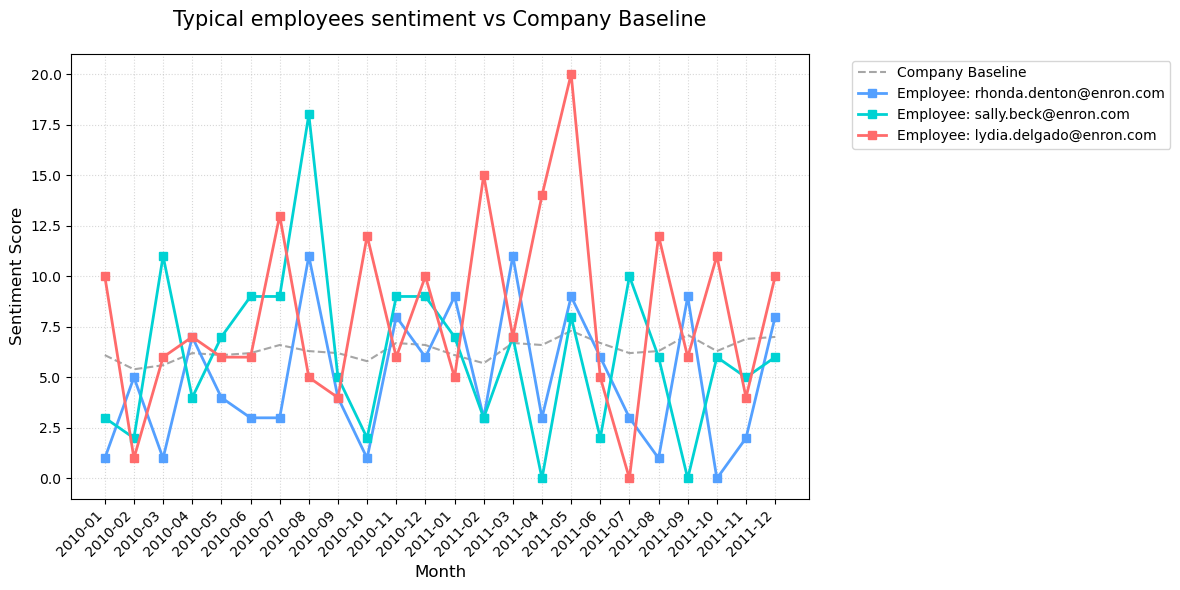

In [34]:
employee_summary = (
    monthly_employee_score
    .groupby('employee')['sentiment_score']
    .mean()
    .sort_values()
)

sample_employees = [
    employee_summary.index[0],
    employee_summary.index[len(employee_summary)//2],
    employee_summary.index[-1]
]

plt.figure(figsize=(12, 6))

plt.plot(company_trend.index, company_trend.values,
         label='Company Baseline', color='gray', linestyle='--', alpha=0.7)

colors = ['#54A0FF', '#00D2D3', '#FF6B6B']
for i, emp in enumerate(sample_employees):
    emp_data = monthly_employee_score[monthly_employee_score['employee'] == emp]
    emp_data = emp_data.sort_values('month')
    plt.plot(emp_data['month'], emp_data['sentiment_score'],
             marker='s', label=f'Employee: {emp}', color=colors[i], linewidth=2)

plt.title('Typical employees sentiment vs Company Baseline', fontsize=15, pad=20)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Sentiment Score', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

This chart compares the monthly emotional scores of three selected employees with the average emotional trend of the entire company. The gray dashed line represents the overall baseline of the company, which remains relatively stable over time. Three employees with the highest average monthly score, near the median, and the lowest score are selected as representatives. The monthly fluctuation of each employee's score is much larger than the company's baseline, and the change in their sentiment scores differs. This suggests that the overall emotional trend may mask differences at the employee level, which supports the necessity of employee level analysis.

### Task4 Employee Ranking

In [35]:
top_positive = (
    monthly_employee_score
    .sort_values(
        by=["month", "sentiment_score", "employee"],
        ascending=[True, False, True]
    )
    .groupby("month")
    .head(3)
    .reset_index(drop=True)
)

top_positive.head(10)


,employee,month,sentiment_score
0,kayne.coulter@enron.com,2010-01,14
1,lydia.delgado@enron.com,2010-01,10
2,eric.bass@enron.com,2010-01,9
3,john.arnold@enron.com,2010-02,12
4,johnny.palmer@enron.com,2010-02,12
5,bobette.riner@ipgdirect.com,2010-02,9
6,sally.beck@enron.com,2010-03,11
7,john.arnold@enron.com,2010-03,8
8,eric.bass@enron.com,2010-03,7
9,kayne.coulter@enron.com,2010-04,11


In [36]:
top_negative = (
    monthly_employee_score
    .sort_values(
        by=["month", "sentiment_score", "employee"],
        ascending=[True, True, True]
    )
    .groupby("month")
    .head(3)
    .reset_index(drop=True)
)

top_negative.head(10)


,employee,month,sentiment_score
0,bobette.riner@ipgdirect.com,2010-01,1
1,rhonda.denton@enron.com,2010-01,1
2,sally.beck@enron.com,2010-01,3
3,lydia.delgado@enron.com,2010-02,1
4,patti.thompson@enron.com,2010-02,1
5,kayne.coulter@enron.com,2010-02,2
6,rhonda.denton@enron.com,2010-03,1
7,don.baughman@enron.com,2010-03,3
8,kayne.coulter@enron.com,2010-03,3
9,eric.bass@enron.com,2010-04,2


Employees are ranked on a monthly basis according to their aggregated sentiment scores. 
For each month, the top three employees with the highest scores and the top three employees 
with the lowest scores are identified. In cases of ties, employees are sorted alphabetically 
to ensure consistent and reproducible rankings.


In [53]:
# Overall employee ranking based on average monthly sentiment score
overall_employee_ranking = (
    monthly_employee_score
    .groupby("employee")["sentiment_score"]
    .mean()
    .reset_index(name="avg_sentiment_score")
    .sort_values("avg_sentiment_score", ascending=False)
    .reset_index(drop=True)
)

overall_employee_ranking["rank"] = range(1, len(overall_employee_ranking) + 1)

print("Overall employee ranking:")
print(overall_employee_ranking.to_string(index=False))

Overall employee ranking:
                   employee  avg_sentiment_score  rank
    lydia.delgado@enron.com             8.125000     1
      john.arnold@enron.com             7.875000     2
   patti.thompson@enron.com             6.833333     3
        eric.bass@enron.com             6.625000     4
       sally.beck@enron.com             6.166667     5
bobette.riner@ipgdirect.com             6.083333     6
     don.baughman@enron.com             6.041667     7
    johnny.palmer@enron.com             6.000000     8
    kayne.coulter@enron.com             4.958333     9
    rhonda.denton@enron.com             4.916667    10


If we want to observe who the top 3 positive and top 3 negative employees are during these 24 months, we can rank them by calculating their average monthly scores.

### Task5 Flight Risk Identification

In [37]:
negative_df = df[df["final_sentiment"] == "Negative"].copy()
negative_df = negative_df.dropna(subset=["date_dt"])
negative_df = negative_df.sort_values(["employee", "date_dt"])

In [38]:
def has_flight_risk(employee_df):
    dates = employee_df["date_dt"].values
    n = len(dates)
    
    left = 0
    for right in range(n):
        while (dates[right] - dates[left]).astype("timedelta64[D]").item().days > 30:
            left += 1
        
        if right - left + 1 >= 4:
            return True
    
    return False


In [39]:
flight_risk_employees = (
    negative_df
    .groupby("employee")
    .filter(has_flight_risk)["employee"]
    .unique()
)

flight_risk_employees


array([], dtype=object)

In [40]:
def max_window_count(employee_df):
    dates = employee_df["date_dt"].values
    n = len(dates)

    left = 0
    max_count = 0

    for right in range(n):
        while (dates[right] - dates[left]).astype("timedelta64[D]").item().days > 30:
            left += 1

        window_count = right - left + 1
        if window_count > max_count:
            max_count = window_count

    return max_count

flight_risk_check = (
    negative_df
    .groupby("employee")
    .apply(max_window_count)
    .reset_index(name="max_negative(30 days)")
    .sort_values("max_negative(30 days)", ascending=False)
)

flight_risk_check.head(20)

,employee,max_negative(30 days)
0,bobette.riner@ipgdirect.com,2
3,john.arnold@enron.com,2
4,johnny.palmer@enron.com,2
5,kayne.coulter@enron.com,2
7,patti.thompson@enron.com,2
9,sally.beck@enron.com,2
1,don.baughman@enron.com,1
2,eric.bass@enron.com,1
6,lydia.delgado@enron.com,1
8,rhonda.denton@enron.com,1


Flight risk employees are identified based on the frequency of negative messages within a rolling 
30-day window. An employee is flagged as a flight risk if they sent four or more negative messages 
within any consecutive 30-day period, regardless of calendar month. This rolling-window approach 
ensures timely detection of sustained dissatisfaction.  
However, the result shows that no employee is flagged as flight risk under the predefined rule of four or more negative emails within any rolling 30-day window. To validate this result, I check the maximum number of negative emails observed within a 30-day window for each employee, and the highest value is only 2. This confirms that the empty result is due to the data itself.


### Task6 Predictive Modeling

In [41]:
monthly_employee_score["sentiment_score"]

0      1
1      9
2      6
3      3
4      3
      ..
235    6
236    0
237    6
238    5
239    6
Name: sentiment_score, Length: 240, dtype: int64

In [42]:
df["message_length"] = df["text"].str.len()
df["word_count"] = df["text"].str.split().str.len()

In [43]:
monthly_features = (
    df
    .groupby(["employee", "month"])
    .agg(
        message_count=("text", "count"),
        avg_message_length=("message_length", "mean"),
        avg_word_count=("word_count", "mean")
    )
    .reset_index()
)

monthly_features.head()


,employee,month,message_count,avg_message_length,avg_word_count
0,bobette.riner@ipgdirect.com,2010-01,2,154.000000,24.500000
1,bobette.riner@ipgdirect.com,2010-02,14,324.285714,48.642857
2,bobette.riner@ipgdirect.com,2010-03,11,314.909091,48.727273
3,bobette.riner@ipgdirect.com,2010-04,6,255.000000,35.500000
4,bobette.riner@ipgdirect.com,2010-05,4,187.750000,32.500000


In [44]:
model_df = pd.merge(
    monthly_employee_score,
    monthly_features,
    on=["employee", "month"],
    how="inner"
)

model_df.head()


,employee,month,sentiment_score,message_count,avg_message_length,avg_word_count
0,bobette.riner@ipgdirect.com,2010-01,1,2,154.000000,24.500000
1,bobette.riner@ipgdirect.com,2010-02,9,14,324.285714,48.642857
2,bobette.riner@ipgdirect.com,2010-03,6,11,314.909091,48.727273
3,bobette.riner@ipgdirect.com,2010-04,3,6,255.000000,35.500000
4,bobette.riner@ipgdirect.com,2010-05,3,4,187.750000,32.500000


In [45]:
from sklearn.model_selection import train_test_split

X = model_df[[
    "message_count",
    "avg_message_length",
    "avg_word_count"
]]

y = model_df["sentiment_score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [46]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)


LinearRegression()

In [47]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = lr.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

mse, r2


(2.5402196724688197, 0.8092600011286611)

The linear regression model achieves an MSE of 2.54 and an R² of 0.81 on the test set. This indicates that the model explains about 81% of the variation in monthly sentiment score and provides a reasonably good fit. Overall, the selected text-related features show useful predictive power for employee-month sentiment patterns.

In [48]:
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": lr.coef_
})

coef_df


,feature,coefficient
0,message_count,0.709873
1,avg_message_length,-0.006612
2,avg_word_count,0.051184


The coefficient results show that message_count has the largest positive effect on monthly sentiment score, with a coefficient of 0.71. In comparison, avg_word_count has only a small positive effect, while avg_message_length has a very small negative effect. Overall, this suggests that email volume is the main factor associated with higher monthly sentiment scores in the model.

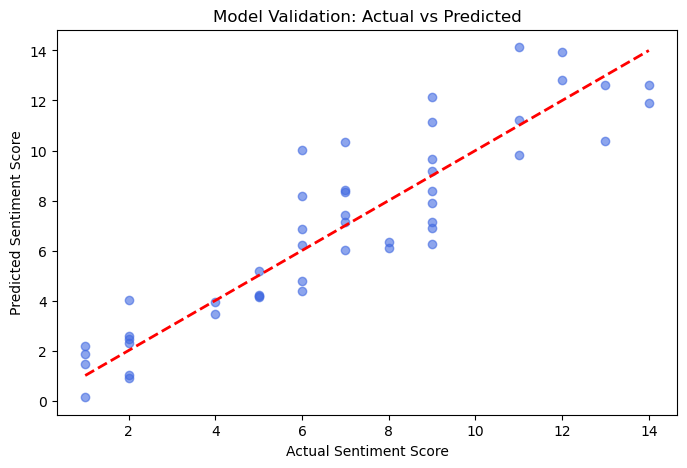

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.6, color='royalblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Sentiment Score")
plt.ylabel("Predicted Sentiment Score")
plt.title("Model Validation: Actual vs Predicted")
plt.show()


The plot shows that most points are relatively close to the reference line, indicating that the model predicts monthly sentiment scores reasonably well. Some prediction errors remain, but the overall fit is fairly strong.

This notebook analyzes employee email communication from multiple perspectives, including emotional tags, time trends, employee level ratings, rankings, Flight risk detection, and predictive modeling. In order to improve the classification quality, a two-step approach was adopted: VADER generates initial labels, and RoBERTa refines the messages that are first identified as negative. The results indicate that positive emotions dominate the dataset, neutral emotions account for a large proportion, and negative emotions are still relatively limited. The monthly analysis also indicates that over time, the overall emotional tone of the company has remained stable and generally positive.  
At the employee level, emotional ratings and rankings reveal differences in communication patterns between individuals, while the rolling 30 day negative information rule helps identify potential flight risk employees. The linear regression model also performed well, with an R ² of approximately 0.81, indicating that communication behavior variables explained a significant portion of monthly emotional changes. Among the predictive factors, the number of messages has the strongest positive correlation with emotions, while the positive impact of average word count is relatively small, and the negative impact of average message length is relatively small. Overall, the research findings indicate that employee communication data is useful and interpretable.  
Finally, no employees were identified as potentially flight prone, therefore the predicted list is empty.